In [27]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

# Paths and config
# Adapt these paths if you move the repository
REPO_ROOT = Path('/Users/trevin/Git/ucsd-phys-139-final')
DATA_DIR = REPO_ROOT / 'data'
MODELS_DIR = REPO_ROOT / 'models'
ARTIFACTS_DIR = DATA_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Pattern for your feature CSVs inside DATA_DIR
# If you later combine to a single file, you can set CSV_PATTERN = 'features.csv'
CSV_PATTERN = 'features_batch_*.csv'

RANDOM_STATE = 42
CONTAMINATION = 0.05  # fraction of points to flag as anomalies
np.random.seed(RANDOM_STATE)

In [28]:
# Load dataset from one or more CSVs in DATA_DIR
csv_paths = sorted(DATA_DIR.glob(CSV_PATTERN))
assert len(csv_paths) > 0, f"No CSV files matching {CSV_PATTERN!r} found in {DATA_DIR}"

dfs = [pd.read_csv(p) for p in csv_paths]
df = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(csv_paths)} file(s) with total shape: {df.shape}")
df.head()


Loaded 18 file(s) with total shape: (8943, 13)


,star_id,period,Q31,Amp,W,K,Std,gamma1,gamma2,R21,R31,phi21,phi31
0,1627611,0.000694,17.367676,2.725798e+07,0.995328,0.790877,13.129725,0.234567,0.896274,0.740679,0.444024,-3.142877,-6.288401
1,1627709,0.001388,31.924316,1.753971e+01,0.998039,0.789019,24.264444,0.136627,0.381863,0.490034,0.354283,1.982006,1.376225
2,1628071,0.001385,632.500000,4.369893e+02,0.960232,0.769158,492.486649,1.294851,24.418117,0.140090,0.234802,-5.508558,-3.561120
3,1628320,0.000694,91.816406,1.380857e+02,0.990501,0.766467,79.168890,0.180369,0.219374,0.355434,0.154320,1.591097,5.526710
4,1628550,0.000704,13.359497,1.861681e+00,0.999504,0.793396,10.110264,0.048886,0.171868,0.131086,0.214648,0.583646,1.538676


In [29]:
# Prepare feature matrix X
# Assume first column is the star ID unless a 'star_id' column is explicitly present
if 'star_id' in df.columns:
    id_col = 'star_id'
else:
    id_col = df.columns[0]

feature_cols = [c for c in df.columns if c != id_col]

X = df[feature_cols].copy()

# Keep a copy of ids
ids = df[id_col].copy()

# Ensure numeric and handle NaNs
X = X.apply(pd.to_numeric, errors='coerce')
X = X.apply(lambda s: s.fillna(s.median()))

X.describe().T


,count,mean,std,min,25%,50%,75%,max
period,8943.0,2.049022e-01,2.762201e+00,0.000639,0.000694,0.000695,0.000695,2.441959e+02
Q31,8943.0,4.295767e+02,1.183333e+04,4.973206,15.220947,24.068359,49.978516,1.064479e+06
Amp,8943.0,2.833610e+09,8.179943e+10,0.658349,3.778437,10.817147,82.273696,5.609183e+12
W,8943.0,9.840565e-01,6.397488e-02,0.065298,0.992194,0.997128,0.999002,9.999556e-01
K,8943.0,7.902136e-01,4.063486e-02,0.138654,0.787174,0.792546,0.796469,9.595537e-01
Std,8943.0,3.019532e+02,7.970981e+03,3.729373,11.439335,18.277552,38.335805,7.201559e+05
gamma1,8943.0,2.313580e-01,1.712368e+00,-11.346429,0.045308,0.123800,0.232140,4.691320e+01
gamma2,8943.0,6.510637e+00,8.252100e+01,-1.780891,0.091880,0.331036,0.829092,2.725002e+03
R21,8943.0,3.476061e-01,5.895480e-01,0.000593,0.153951,0.285958,0.480000,5.096348e+01
R31,8943.0,2.581371e-01,1.995111e-01,0.000187,0.100949,0.217581,0.395673,1.987793e+00


In [30]:
# Train IsolationForest
iso = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X)

# Keep model in variable for downstream cells
iso


,n_estimators,300
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [31]:
# Scores and anomaly flags
# Higher anomaly_score => more anomalous
anomaly_score = -iso.score_samples(X)
preds = iso.predict(X)  # 1 for normal, -1 for anomaly
is_anomaly = (preds == -1)

results = pd.DataFrame({
    'id': ids.values,
    'anomaly_score': anomaly_score,
    'is_anomaly': is_anomaly,
})

# Top-N anomalies
TOP_N = 20
results_sorted = results.sort_values('anomaly_score', ascending=False)
results_sorted.head(TOP_N)


,id,anomaly_score,is_anomaly
4148,130943601,0.808543,True
2126,55298910,0.779808,True
6968,163024899,0.763222,True
3835,107139259,0.760154,True
3067,80840548,0.752635,True
3548,101775388,0.751632,True
6855,162484935,0.750106,True
8167,181015118,0.746339,True
3135,83153075,0.744407,True
6722,158747617,0.742839,True


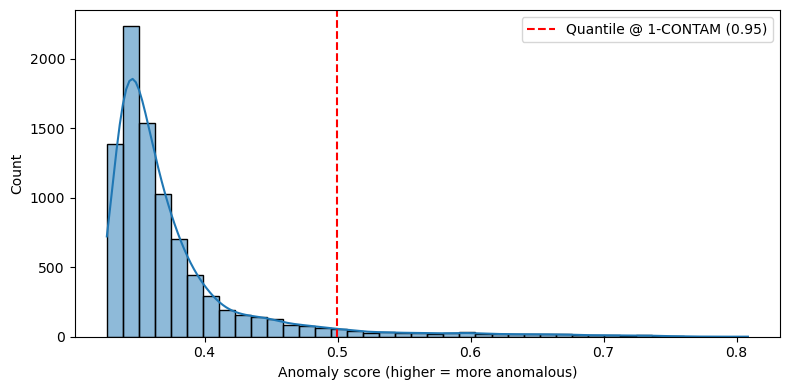

0.49929695621575887

In [32]:
# Score distribution and threshold visualization
plt.figure(figsize=(8, 4))
sns.histplot(anomaly_score, bins=40, kde=True)
plt.xlabel('Anomaly score (higher = more anomalous)')
plt.ylabel('Count')

# Visualize expected anomaly fraction
q = np.quantile(anomaly_score, 1 - CONTAMINATION)
plt.axvline(q, color='red', linestyle='--', label=f'Quantile @ 1-CONTAM ({1-CONTAMINATION:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

q


In [33]:
# Save artifacts
model_path = MODELS_DIR / 'isolation_forest.joblib'
scores_path = ARTIFACTS_DIR / 'anomaly_scores.csv'

# Persist model and results
dump(iso, model_path)
results_sorted.to_csv(scores_path, index=False)

model_path, scores_path


(PosixPath('/Users/trevin/Git/ucsd-phys-139-final/models/isolation_forest.joblib'),
 PosixPath('/Users/trevin/Git/ucsd-phys-139-final/data/anomaly_scores.csv'))